In [1]:
# ============================================================
# 1. Importación de librerías
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor   # Si no hay XGBoost

from sklearn.metrics import mean_squared_error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import IsolationForest

# ============================================================
# 2. Carga del dataset
# ============================================================
dfR = pd.read_csv(r"C:/Users/carpi/Downloads/R-JD/Practica 3/practica_red_electrica_dirty.csv")

dfR.info()


<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   fecha        240 non-null    str  
 1   subestacion  179 non-null    str  
 2   region       185 non-null    str  
 3   tipo_red     240 non-null    str  
 4   consumo_mw   238 non-null    str  
dtypes: str(5)
memory usage: 19.2 KB


In [2]:
# ============================================================
# 3. Limpieza de datos
# ============================================================
import numpy as np

dfR["region"] = dfR["region"].astype(str).str.strip().replace("", np.nan)
dfR["tipo_red"] = dfR["tipo_red"].astype(str).str.strip().replace("", np.nan)
dfR["subestacion"] = dfR["subestacion"].astype(str).str.strip().replace("", np.nan)
dfR["consumo_mw"] = dfR["consumo_mw"].astype(str).str.strip().replace("", np.nan)

dfR["consumo_mw"] = dfR["consumo_mw"].str.replace(r"[^0-9.]", "", regex=True)
dfR["consumo_mw"] = pd.to_numeric(dfR["consumo_mw"])


dfR["fecha"] = pd.to_datetime(dfR["fecha"], errors="coerce")

#Imputar vacío como "desconocido"
dfR["region"] = dfR["region"].fillna("desconocido")
dfR["tipo_red"] = dfR["tipo_red"].fillna("desconocido")
dfR["subestacion"] = dfR["subestacion"].fillna("desconocido")
dfR["consumo_mw"] = dfR["consumo_mw"].fillna(dfR["consumo_mw"].median())

dfR

,fecha,subestacion,region,tipo_red,consumo_mw
0,2024-01-01,NORTE_01,desconocido,Media,1324.178538
1,2024-01-02,CENTRO_02,Centro,Alta,1165.433925
2,2024-01-03,CENTRO_02,desconocido,Media,1361.922135
3,2024-01-04,desconocido,desconocido,Media,1580.757464
4,2024-01-05,CENTRO_02,desconocido,Alta,1141.461656
...,...,...,...,...,...
235,2024-08-23,NORTE_01,Norte,desconocido,1358.479756
236,2024-08-24,desconocido,Norte,desconocido,693.714353
237,2024-08-25,SUR_03,desconocido,Alta,1246.613579
238,2024-08-26,NORTE_01,Centro,desconocido,1034.553384


In [3]:

dfR.to_csv("C:/Users/carpi/Downloads/R-JD/Practica 3/df_listo_para_tratar_outliers_by_python.csv")
dfR.isna().sum()

fecha          0
subestacion    0
region         0
tipo_red       0
consumo_mw     0
dtype: int64

In [4]:
#Tratamiento de outliers (IQR, Z-score, Isolation Forest).
dfO = dfR[["consumo_mw"]].copy()
# ===========================================
# 2. Detección con IQR
# ===========================================
Q1 = dfR["consumo_mw"].quantile(0.25)
Q3 = dfR["consumo_mw"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

dfR["outlier_IQR"] = (dfR["consumo_mw"] < lower) | (dfR["consumo_mw"] > upper)

print("Outliers detectados (IQR):")
print(dfR[dfR["outlier_IQR"]])

Outliers detectados (IQR):
         fecha  subestacion       region     tipo_red   consumo_mw  \
74  2024-03-15       SUR_03        Norte  desconocido   545.063724   
80  2024-03-21  desconocido        Norte  desconocido  5000.000000   
120 2024-04-30       SUR_03       Centro  desconocido   100.000000   
179 2024-06-28  desconocido       Centro        Media  1880.042292   
209 2024-07-28  desconocido  desconocido         Baja  2163.182873   

     outlier_IQR  
74          True  
80          True  
120         True  
179         True  
209         True  


In [5]:
np.abs(stats.zscore(dfR["consumo_mw"]))

array([3.23407300e-01, 1.28901608e-01, 4.30949625e-01, 1.05447421e+00,
       1.97205472e-01, 3.04129507e-02, 1.09449455e+00, 5.16247431e-01,
       3.64829726e-01, 3.56064321e-01, 3.60515412e-01, 3.62162343e-01,
       1.41942017e-01, 1.39328391e+00, 1.25910929e+00, 4.30942538e-01,
       7.51874498e-01, 1.93432232e-01, 6.77218170e-01, 1.03642747e+00,
       1.01360042e+00, 1.91238300e-01, 1.76888523e-02, 1.04529195e+00,
       4.18188558e-01, 4.85996128e-02, 8.50290609e-01, 2.37204886e-01,
       4.58260901e-01, 2.38192727e-01, 4.59021605e-01, 1.28900492e+00,
       4.00273162e-02, 7.83843358e-01, 5.55503608e-01, 9.00046329e-01,
       1.18365112e-01, 1.42632843e+00, 9.76508645e-01, 1.09815572e-01,
       1.39327160e-02, 9.16563882e-02, 1.12791727e-01, 2.44895636e-01,
       1.08359619e+00, 5.43173574e-01, 3.58535926e-01, 7.22598111e-01,
       2.14353801e-01, 1.28626464e+00, 2.00439081e-01, 3.04715401e-01,
       5.12599155e-01, 4.05297320e-01, 7.03990343e-01, 6.32958052e-01,
      

In [6]:
# ===========================================
# 3. Detección con Z-score
# z = x - media / SD
# ===========================================
dfR["z_score"] = np.abs(stats.zscore(dfR["consumo_mw"])) #Calcula qué tan lejos está cada valor de ventas respecto al promedio, medido en desviaciones estándar, y lo deja en valor positivo

dfR["outlier_Z"] = dfR["z_score"] > 3

print("Outliers detectados (Z-score):")
print(dfR[dfR["outlier_Z"]])

Outliers detectados (Z-score):
         fecha  subestacion  region     tipo_red  consumo_mw  outlier_IQR  \
80  2024-03-21  desconocido   Norte  desconocido      5000.0         True   
120 2024-04-30       SUR_03  Centro  desconocido       100.0         True   

       z_score  outlier_Z  
80   10.796876       True  
120   3.164628       True  


In [7]:
# ===========================================
# 4. Detección con Isolation Forest
#Isolation Forest detecta outliers aislándolos
# ===========================================
iso = IsolationForest(contamination=0.03, random_state=42) #  3% de outliers  tiene que estar entre 0.02 a 0.07
dfR["outlier_IF"] = iso.fit_predict(dfR[["consumo_mw"]])

# -1 es outlier
print("Outliers detectados (Isolation Forest):")
print(dfR[dfR["outlier_IF"] == -1])

Outliers detectados (Isolation Forest):
         fecha  subestacion       region     tipo_red   consumo_mw  \
74  2024-03-15       SUR_03        Norte  desconocido   545.063724   
80  2024-03-21  desconocido        Norte  desconocido  5000.000000   
113 2024-04-23    CENTRO_02  desconocido         Alta  1815.810528   
120 2024-04-30       SUR_03       Centro  desconocido   100.000000   
179 2024-06-28  desconocido       Centro        Media  1880.042292   
209 2024-07-28  desconocido  desconocido         Baja  2163.182873   
220 2024-08-08  desconocido       Centro  desconocido  1778.664642   
236 2024-08-24  desconocido        Norte  desconocido   693.714353   

     outlier_IQR    z_score  outlier_Z  outlier_IF  
74          True   1.896514      False          -1  
80          True  10.796876       True          -1  
113        False   1.724208      False          -1  
120         True   3.164628       True          -1  
179         True   1.907222      False          -1  
209        

In [12]:
#TRATAMIENTO DE OUTLIERS
#eliminarlos
df_sin_outliers = dfR[~dfR["outlier_IQR"]]
print(len(dfR))
print("-")
print(len(df_sin_outliers))
np.clip(dfR["consumo_mw"], lower, upper)
#Winsorizar --> Sustituye los valores extremos por los límites superior e inferior.
df_winsor = dfR.copy()
df_winsor["consumo_mw"] = np.clip(dfR["consumo_mw"], lower, upper)

240
-
235


In [13]:
#Imputación (mediana o media)  --> Todo lo que es outlier lo vuelvo la media
df_imputado = dfR.copy()
mediana = dfR["consumo_mw"].median()
df_imputado.loc[dfR["outlier_IQR"], "consumo_mw"] = mediana
#transformacion log
dfR["consumo_log"] = np.log(dfR["consumo_mw"])

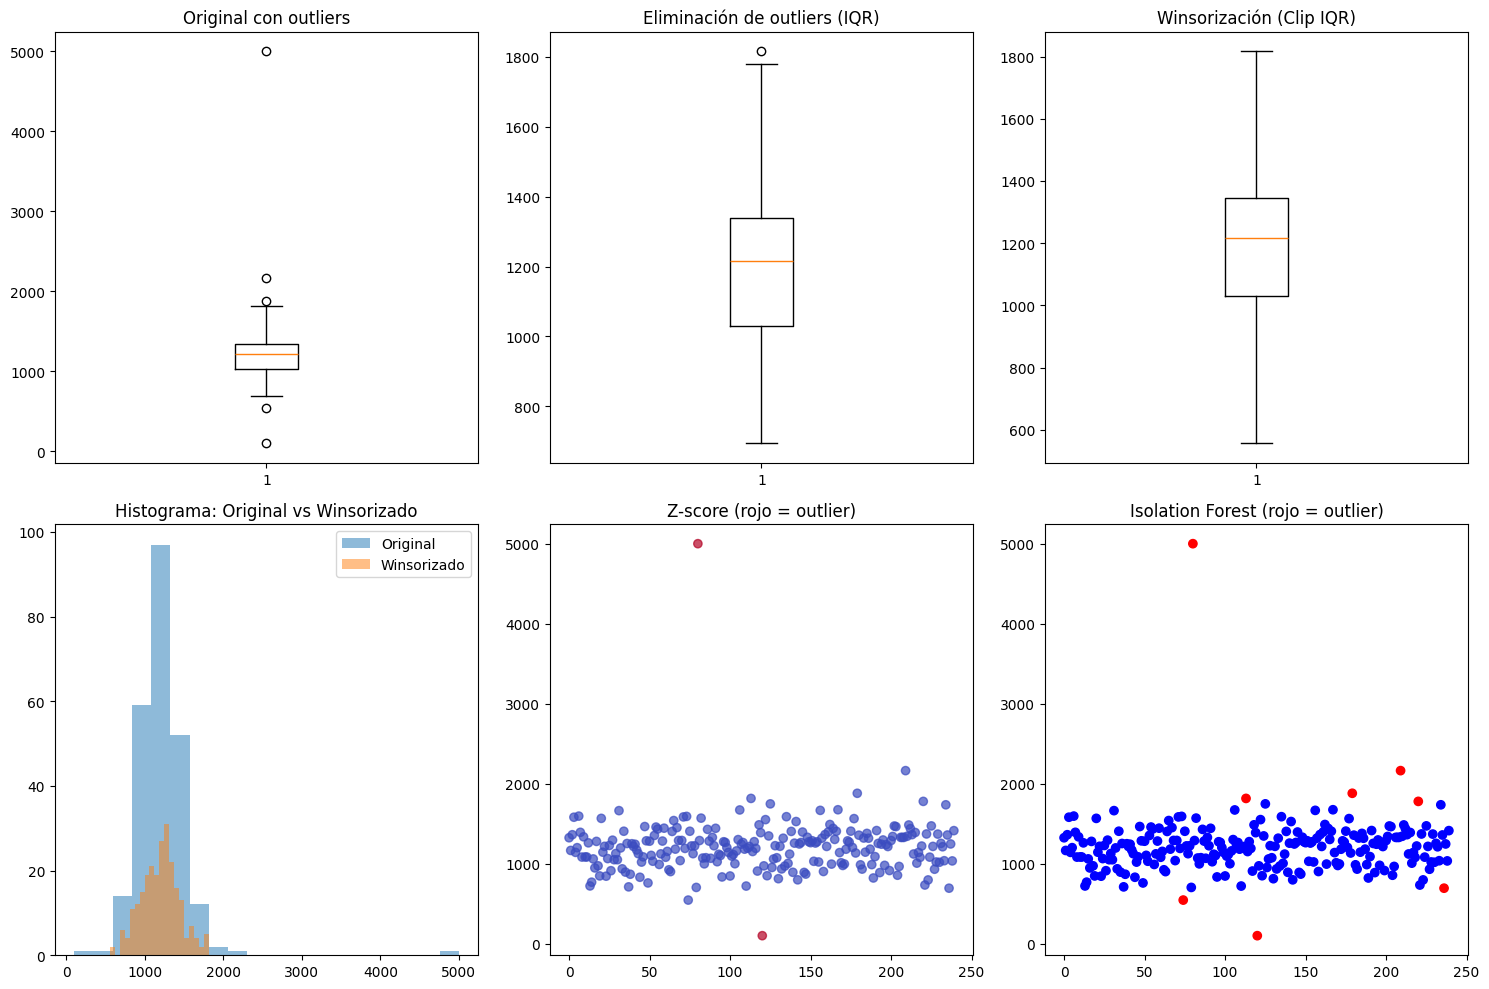

In [14]:
plt.figure(figsize=(15,10))

# --------------------------------------------
# Gráfica 1: Boxplot original
# --------------------------------------------
plt.subplot(2,3,1)
plt.boxplot(dfR["consumo_mw"])
plt.title("Original con outliers")

# --------------------------------------------
# Gráfica 2: Eliminación
# --------------------------------------------
plt.subplot(2,3,2)
plt.boxplot(df_sin_outliers["consumo_mw"])
plt.title("Eliminación de outliers (IQR)")

# --------------------------------------------
# Gráfica 3: Winsorización
# --------------------------------------------
plt.subplot(2,3,3)
plt.boxplot(df_winsor["consumo_mw"])
plt.title("Winsorización (Clip IQR)")

# --------------------------------------------
# Gráfica 4: Histograma comparativo
# --------------------------------------------
plt.subplot(2,3,4)
plt.hist(dfR["consumo_mw"], bins=20, alpha=0.5, label="Original")
plt.hist(df_winsor["consumo_mw"], bins=20, alpha=0.5, label="Winsorizado")
plt.title("Histograma: Original vs Winsorizado")
plt.legend()


# --------------------------------------------
# Gráfica 5: Z-score vs IQR
# --------------------------------------------
plt.subplot(2,3,5)
plt.scatter(range(len(dfR)), dfR["consumo_mw"], 
            c=dfR["outlier_Z"], cmap="coolwarm", alpha=0.7)
plt.title("Z-score (rojo = outlier)")
# --------------------------------------------
# Gráfica 6: Isolation Forest
# --------------------------------------------
plt.subplot(2,3,6)
colors = dfR["outlier_IF"].map({1: "blue", -1: "red"})
plt.scatter(range(len(dfR)), dfR["consumo_mw"], c=colors)
plt.title("Isolation Forest (rojo = outlier)")

plt.tight_layout()
plt.show()

In [26]:
# Winsorización
df_winsor = dfR.copy()
df_winsor["consumo_mw"] = np.clip(df_winsor["consumo_mw"], lower, upper)

# Crear dataset final
df_listo = df_winsor.copy()

# Eliminar columnas auxiliares si existen
cols_drop = ["outlier_IQR", "outlier_Z", "outlier_IF", "z_score"]
df_listo = df_listo.drop(columns=[c for c in cols_drop if c in df_listo.columns])

# Guardar archivo
df_listo.to_csv(
    "C:/Users/carpi/Downloads/R-JD/Practica 3/df_listo_outliers_tratados_python.csv",
    index=False
)

df_listo

,fecha,subestacion,region,tipo_red,consumo_mw,consumo_log
0,2024-01-01,NORTE_01,desconocido,Media,1324.178538,7.188548
1,2024-01-02,CENTRO_02,Centro,Alta,1165.433925,7.060849
2,2024-01-03,CENTRO_02,desconocido,Media,1361.922135,7.216652
3,2024-01-04,desconocido,desconocido,Media,1580.757464,7.365659
4,2024-01-05,CENTRO_02,desconocido,Alta,1141.461656,7.040065
...,...,...,...,...,...,...
235,2024-08-23,NORTE_01,Norte,desconocido,1358.479756,7.214122
236,2024-08-24,desconocido,Norte,desconocido,693.714353,6.542060
237,2024-08-25,SUR_03,desconocido,Alta,1246.613579,7.128186
238,2024-08-26,NORTE_01,Centro,desconocido,1034.553384,6.941725


In [ ]:
# Extraer características temporales
dfR["anio"] = dfR["fecha"].dt.year
dfR["mes"] = dfR["fecha"].dt.month
dfR["dia"] = dfR["fecha"].dt.day
dfR["dia_semana"] = dfR["fecha"].dt.weekday


In [ ]:
#Construya una serie temporal diaria del consumo total.


In [ ]:
#Descomponga la serie con STL.

In [ ]:
#Pronostique con Prophet

In [ ]:
#- Modele con ML (Regresión Lineal, Random Forest, Gradient Boosting).


In [ ]:
# Use validación cruzada k-fold y compare RMSE.


In [ ]:
#- Modele un sistema híbrido Prophet + ML.

In [ ]:
# Variables feature y target
X = df[["cliente", "canal", "region", "anio", "mes", "dia", "hora", "dia_semana"]]
y = df["ventas"]

# Identificar columnas categóricas
cat_cols = ["cliente", "canal", "region"]

# Preprocesamiento: OneHotEncoder para categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)


In [ ]:
# ============================================================
# 5. División Train/Test
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


In [ ]:
# ============================================================
# 6. Definir 3 modelos
# ============================================================
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [ ]:
# ============================================================
# 7. Validación Cruzada (5-fold) y comparación
# ============================================================
resultados = {}

for nombre, modelo in modelos.items():
    # Construimos pipeline: preprocesamiento + modelo
    pipe = Pipeline(steps=[("prep", preprocessor),
                          ("model", modelo)])
    
    # Cross validation RMSE (por eso -score, lo convertimos)
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=5,
                             scoring="neg_root_mean_squared_error")
    print(nombre)
    print(scores)
    rmse_promedio = -scores.mean()
    resultados[nombre] = rmse_promedio
    print(f"Modelo: {nombre} - RMSE promedio CV: {rmse_promedio:.2f}")


In [ ]:
# ============================================================
# 8. GRÁFICA 1 - Comparación de modelos (RMSE)
# ============================================================
plt.figure(figsize=(6,4))
plt.bar(resultados.keys(), resultados.values(), color=["#1f77b4", "#ff7f0e", "#2ca02c"])

plt.ylabel("RMSE CV promedio")
plt.title("Comparación de modelos")
plt.tight_layout()
plt.show()



In [ ]:

# ============================================================
# 8. Seleccionar el mejor modelo
# ============================================================
mejor_modelo_nombre = min(resultados, key=resultados.get)
mejor_modelo = modelos[mejor_modelo_nombre]

print("\nMejor modelo según CV:", mejor_modelo_nombre)


In [ ]:

# ============================================================
# 9. Entrenar modelo ganador en todo el train
# ============================================================
pipeline_final = Pipeline([
    ("prep", preprocessor),
    ("model", mejor_modelo)
])

pipeline_final.fit(X_train, y_train)

In [ ]:


# ============================================================
# 10. Evaluación Final en Test
# ============================================================
y_pred = pipeline_final.predict(X_test)
rmse_test = mean_squared_error(y_test, y_pred)

print(f"RMSE en Test del modelo ganador ({mejor_modelo_nombre}): {rmse_test:.2f}")


In [ ]:

# ============================================================
# 10. GRÁFICA 2 - Predicción vs Real
# ============================================================
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, alpha=0.5, color="#1f77b4")

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", linewidth=2)

plt.xlabel("Ventas reales")
plt.ylabel("Ventas predichas")
plt.title("Predicción vs Real")
plt.tight_layout()
plt.show()